# Práctica 3.6 – Redes Neuronales Convolucionales (CNN)
## Reconocimiento de Emociones Faciales con FER-2013

**Equipo 10**  
**Materia:** Minería de Datos  
**Profesor:** Jose Roberto Olvera Lopez  
**Facultad de Ingeniería, UNAM**  
**Fecha:** Mayo 2026

---
## 1. Propósito de la Práctica

### Contexto: El Estudio Original

En 2020, Sturm et al. (UCSF) publicaron un ensayo clínico aleatorizado con 60 adultos mayores (60–90 años) en el que evaluaron si caminatas breves diseñadas para cultivar **asombro** (*awe*) podían mejorar el bienestar emocional. Durante ocho semanas, los participantes tomaban tres *selfies* por caminata (1,184 fotos en total) y llenaban encuestas de estado emocional.

Para analizar los cambios conductuales en las fotografías, los autores emplearon **MATLAB Image Processing Toolbox**: binarizaron cada imagen en píxeles "yo" vs. "fondo" y calcularon el *self-size* —qué proporción del encuadre ocupa la persona— como indicador indirecto de auto-enfoque. Adicionalmente, codificaron **manualmente** la intensidad de sonrisa en cada foto. Los resultados mostraron que los participantes del grupo *awe* progresivamente cedieron más espacio al entorno y sonrieron con mayor intensidad semana a semana.

### Caso de Negocio (Extensión Propuesta)

El protocolo de medición del estudio original tiene dos limitaciones prácticas importantes:

1. **Escalabilidad**: la codificación manual de sonrisas es costosa y subjetiva; MATLAB requiere umbralización artesanal por sesión.
2. **Riqueza emocional**: el *self-size* captura comportamiento de encuadre, no emoción directamente; la codificación manual solo distingue intensidad de sonrisa, no el espectro emocional completo.

Una extensión natural del estudio consistiría en **reemplazar ambas métricas por un clasificador automático de expresiones faciales**. Dado el corpus de selfies ya recolectado —y ante la posibilidad de replicar el protocolo a mayor escala— un equipo de investigación podría entrenar una CNN capaz de clasificar el estado emocional del participante en cada foto y así:

- Rastrear **trayectorias emocionales longitudinales** (semana 1 → semana 8) de forma automática.
- Comparar la distribución de emociones entre el grupo *awe* y el grupo control a lo largo del tiempo.
- Probar la hipótesis de que el grupo *awe* exhibirá un incremento progresivo en clasificaciones `happy` y una reducción en `neutral`/`sad`, en línea con los hallazgos del estudio original.
- Escalar el protocolo a estudios con mayor número de participantes sin incremento proporcional en costo de análisis.

Las selfies recopiladas en el estudio original no están disponibles públicamente —los participantes son adultos mayores y los datos permanecen bajo resguardo por consideraciones éticas y de privacidad—, por lo que este trabajo entrena el clasificador sobre el dataset público FER-2013 como proxy. FER-2013 ofrece la misma tarea de clasificación (7 emociones, imágenes de rostros en condiciones variables) y permite validar la arquitectura antes de su eventual aplicación sobre el corpus del estudio.



### Objetivo Técnico

Entrenar una **Red Neuronal Convolucional (CNN)** capaz de clasificar imágenes de rostros humanos en **7 categorías de emoción**:

| Clase | Emoción |
|-------|----------|
| 0 | Angry (Enojado) |
| 1 | Disgust (Disgusto) |
| 2 | Fear (Miedo) |
| 3 | Happy (Feliz) |
| 4 | Sad (Triste) |
| 5 | Surprise (Sorpresa) |
| 6 | Neutral (Neutral) |

### Dataset: FER-2013

- **Fuente:** [Kaggle – FER-2013](https://www.kaggle.com/datasets/msambare/fer2013)
- **Tamaño:** ~35,000 imágenes en escala de grises de 48×48 píxeles
- **Estructura:** Carpetas `train/` y `test/` con subcarpetas por emoción
- **Clases:** 7 emociones (distribución desbalanceada; `happy` es la clase dominante)

---
## 2. Instalación y Extracción del Dataset desde Kaggle

In [1]:
# Instalar la API de Kaggle si no está disponible
%pip install kaggle --quiet
# Instalar herramientas de data science si no están disponibles
%pip install numpy matplotlib tensorflow scikit-learn --quiet


[notice] A new release of pip is available: 24.0 -> 26.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 24.0 -> 26.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


### Configuración de credenciales Kaggle

Para descargar el dataset se necesita una clave API de Kaggle:

1. Ve a [kaggle.com](https://www.kaggle.com) → *Account* → *API* → **Create New Token**
2. Copia tu clave API y guárdala en tu máquina.
3. Colócalo en `~/.kaggle/access_token` (Linux/Mac) o `C:\Users\TU_USUARIO\.kaggle\access_token` (Windows) o donde quieras.

Posteriormente, ejecutar la siguiente celda para cargar las credenciales:

In [2]:
import os
import json

# Ajustar esta ruta si tu archivo de credenciales está en otro lugar
kaggle_dir = os.path.expanduser('~/.kaggle')
os.makedirs(kaggle_dir, exist_ok=True)

# Verificar que las credenciales existen
kaggle_access_token_path = os.path.join(kaggle_dir, 'access_token')
if os.path.exists(kaggle_access_token_path):
    os.chmod(kaggle_access_token_path, 0o600)
    print('✅ access_token encontrado correctamente')
else:
    print('❌ access_token no encontrado. Sigue las instrucciones de la celda anterior.')

✅ access_token encontrado correctamente


In [3]:
# Descargar el dataset FER-2013 desde Kaggle si no está ya descargado
dataset_path = './data/fer2013'
if not os.path.exists(dataset_path):
  !kaggle datasets download -d msambare/fer2013 --unzip -p ./data/fer2013
print('✅ Dataset descargado y descomprimido en ./data/fer2013/')

✅ Dataset descargado y descomprimido en ./data/fer2013/


In [4]:
# Verificar estructura del dataset
import os

data_root = './data/fer2013'

for split in ['train', 'test']:
    split_path = os.path.join(data_root, split)
    if os.path.exists(split_path):
        print(f'\n📂 {split}/')
        total = 0
        for emotion in sorted(os.listdir(split_path)):
            emotion_path = os.path.join(split_path, emotion)
            count = len(os.listdir(emotion_path))
            total += count
            print(f'   {emotion:12s}: {count:5d} imágenes')
        print(f'   {"TOTAL":12s}: {total:5d} imágenes')
    else:
        print(f'⚠️  Carpeta {split}/ no encontrada en {data_root}')


📂 train/
   angry       :  3995 imágenes
   disgust     :   436 imágenes
   fear        :  4097 imágenes
   happy       :  7215 imágenes
   neutral     :  4965 imágenes
   sad         :  4830 imágenes
   surprise    :  3171 imágenes
   TOTAL       : 28709 imágenes

📂 test/
   angry       :   958 imágenes
   disgust     :   111 imágenes
   fear        :  1024 imágenes
   happy       :  1774 imágenes
   neutral     :  1233 imágenes
   sad         :  1247 imágenes
   surprise    :   831 imágenes
   TOTAL       :  7178 imágenes


---
## 3. Importar Bibliotecas

Se utilizó numpy, pandas, matplotlib para análisis y visualización; TensorFlow/Keras para construir y entrenar la CNN; y scikit-learn para métricas de evaluación.

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import classification_report, confusion_matrix

I0000 00:00:1777654070.326372   68182 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


---
## 4. Carga y Exploración del Dataset

Se utiliza `ImageDataGenerator` para cargar las imágenes directamente desde la estructura de carpetas del dataset, asignando etiquetas automáticamente a partir del nombre de cada subdirectorio. A continuación se visualizan ejemplos de imágenes por clase para verificar la correcta carga y observar las diferencias visuales entre emociones.

Found 28709 images belonging to 7 classes.
Found 7178 images belonging to 7 classes.


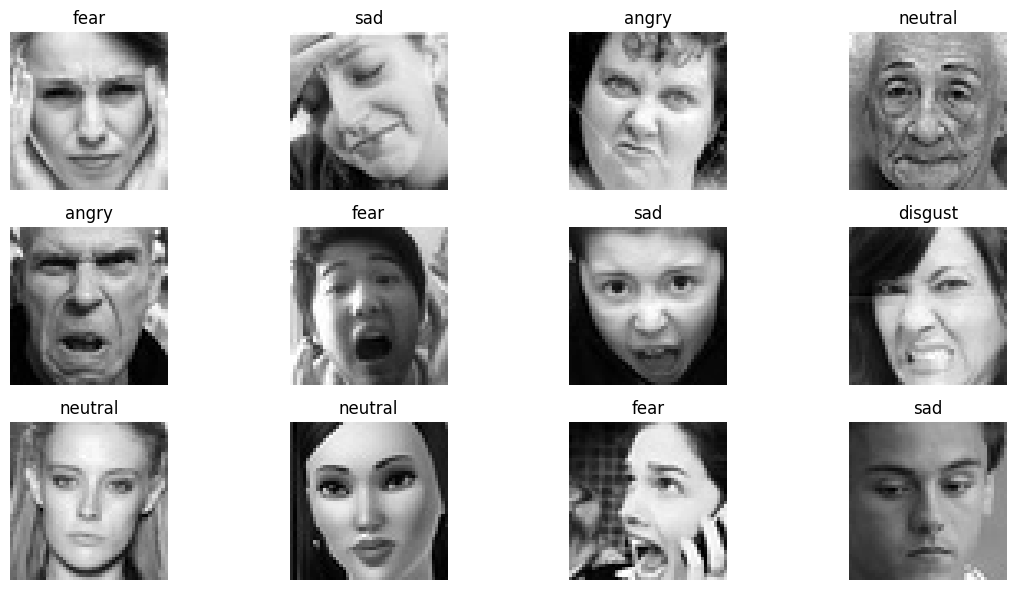

In [6]:
def load_data(data_dir, target_size=(48, 48), batch_size=64):
  datagen = ImageDataGenerator(rescale=1./255)
  generator = datagen.flow_from_directory(
      data_dir,
      target_size=target_size,
      color_mode='grayscale',
      batch_size=batch_size,
      class_mode='categorical',
      shuffle=True
  )
  return generator
  
train_generator = load_data('./data/fer2013/train')
test_generator = load_data('./data/fer2013/test')

# Visualizar algunas imágenes de entrenamiento
class_labels = list(train_generator.class_indices.keys())
plt.figure(figsize=(12, 6))
for i in range(12):
    img, label = next(train_generator)
    plt.subplot(3, 4, i+1)
    plt.imshow(img[0].reshape(48, 48), cmap='gray')
    plt.title(class_labels[np.argmax(label[0])])
    plt.axis('off')
plt.tight_layout()
plt.show()

---
## 5. Preprocesamiento de Imágenes

Se redefinen los generadores de datos aplicando **data augmentation** al conjunto de entrenamiento para aumentar artificialmente la variedad de ejemplos y mejorar la generalización del modelo. Las transformaciones aplicadas son conservadoras para no distorsionar rasgos faciales relevantes: rotaciones leves (±10°), desplazamientos horizontales y verticales (10%), volteo horizontal y zoom moderado (10%).

El generador de prueba aplica **únicamente normalización** (`rescale=1./255`), sin augmentation, para evaluar el modelo en condiciones realistas. Ambos generadores redefinen `train_generator` y `test_generator` que serán usados en el entrenamiento.

In [7]:
# Generador con data augmentation para entrenamiento
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.1
)

# Generador sin augmentation para evaluación (solo normalización)
test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    './data/fer2013/train',
    target_size=(48, 48),
    color_mode='grayscale',
    batch_size=64,
    class_mode='categorical',
    shuffle=True
)

test_generator = test_datagen.flow_from_directory(
    './data/fer2013/test',
    target_size=(48, 48),
    color_mode='grayscale',
    batch_size=64,
    class_mode='categorical',
    shuffle=False
)

print(f'Train: {train_generator.samples} imágenes | {train_generator.num_classes} clases')
print(f'Test:  {test_generator.samples} imágenes  | {test_generator.num_classes} clases')

Found 28709 images belonging to 7 classes.
Found 7178 images belonging to 7 classes.
Train: 28709 imágenes | 7 clases
Test:  7178 imágenes  | 7 clases


---
## 6. Definición del Modelo CNN

La red neuronal convolucional (CNN) propuesta se compone de las siguientes capas:
1. **Capa de Entrada**: Acepta imágenes de 48×48 píxeles en escala de grises (shape: 48×48×1).
2. **Bloque Convolucional 1**:
   - Conv2D con 32 filtros, tamaño de kernel 3×3, activación ReLU, padding 'same'.
   - MaxPooling2D con tamaño de pool 2×2.
3. **Bloque Convolucional 2**:
   - Conv2D con 64 filtros, tamaño de kernel 3×3, activación ReLU, padding 'same'.
   - MaxPooling2D con tamaño de pool 2×2.
4. **Bloque Convolucional 3**:
   - Conv2D con 128 filtros, tamaño de kernel 3×3, activación ReLU, padding 'same'.
   - MaxPooling2D con tamaño de pool 2×2.
5. **Capa de Aplanamiento**: Convierte la salida 3D del último bloque convolucional en un vector 1D.
6. **Capa Densa 1**: 256 unidades con activación ReLU.
7. **Capa de Salida**: 7 unidades (una por clase de emoción) con activación softmax para clasificación multiclase.

La razón de esta arquitectura es que los bloques convolucionales permiten extraer características espaciales jerárquicas de las imágenes, mientras que las capas densas al final permiten aprender combinaciones no lineales de estas características para realizar la clasificación.

In [8]:
# Construir el modelo CNN
model = Sequential([
    # Capa de convolución 1 (32 filtros, tamaño 3x3)
    Conv2D(32, (3, 3), activation='relu', input_shape=(48, 48, 1)),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    
    # Capa de convolución 2 (64 filtros, tamaño 3x3)
    Conv2D(64, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    
    # Capa de convolución 3 (128 filtros, tamaño 3x3)
    Conv2D(128, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    
    # Capa de aplanamiento y clasificación
    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(7, activation='softmax')  # 7 clases de emociones
])

/home/nahtie/Desktop/P6-Mineria/.venv/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1777654074.434388   68182 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 9573 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3060, pci bus id: 0000:01:00.0, compute capability: 8.6


---
## 7. Entrenamiento del Modelo

El modelo se compila con el optimizador **Adam**, ampliamente utilizado en clasificación de imágenes por su capacidad de adaptar dinámicamente la tasa de aprendizaje por parámetro, acelerando la convergencia. La función de pérdida es `categorical_crossentropy`, adecuada para clasificación multiclase con etiquetas one-hot encoded, y se monitorea `accuracy` como métrica principal.

El entrenamiento se configura con un máximo de **50 épocas** y tamaño de lote de 64, pero el número real de épocas es controlado automáticamente por los siguientes **callbacks**:

| Callback | Parámetros clave | Función |
|---|---|---|
| `ModelCheckpoint` | `monitor='val_accuracy'`, `save_best_only=True` | Guarda el modelo en `best_model.keras` cada vez que `val_accuracy` mejora. Garantiza conservar el mejor modelo aunque el entrenamiento continúe deteriorándose después. |
| `ReduceLROnPlateau` | `factor=0.5`, `patience=3`, `min_lr=1e-6` | Reduce el learning rate a la mitad si `val_loss` no mejora durante 3 épocas consecutivas. Ayuda a refinar el ajuste cuando el optimizador empieza a oscilar alrededor del mínimo. |
| `EarlyStopping` | `patience=8`, `restore_best_weights=True` | Detiene el entrenamiento si `val_loss` no mejora en 8 épocas y restaura automáticamente los pesos del mejor modelo registrado. Evita overfitting y tiempo de cómputo innecesario. |

Esta combinación resuelve dos problemas observados en la primera ejecución: la **volatilidad** de `val_accuracy` entre épocas (atenuada por `ReduceLROnPlateau`) y la pérdida del mejor checkpoint al guardar únicamente el modelo final (resuelta por `ModelCheckpoint` y `restore_best_weights`).

In [9]:
callbacks = [
    ModelCheckpoint(
        'best_model.keras',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-6,
        verbose=1
    ),
    EarlyStopping(
        monitor='val_loss',
        patience=8,
        restore_best_weights=True,
        verbose=1
    ),
]

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.fit(train_generator, epochs=50, validation_data=test_generator, callbacks=callbacks)
model.summary()

Epoch 1/50


I0000 00:00:1777654075.296184   68182 generator_dataset_op.cc:213] Memory patch applied: M_TRIM_THRESHOLD=128 kb was set.
I0000 00:00:1777654076.775123   68426 service.cc:153] XLA service 0x7efea403aad0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1777654076.775139   68426 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 3060, Compute Capability 8.6 (Driver: 13.2.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.21.1)
I0000 00:00:1777654076.819238   68426 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1777654077.090487   68426 cuda_dnn.cc:461] Loaded cuDNN version 92101
I0000 00:00:1777654077.140555   68426 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_3382__.62
I0000 00:00:1777654079.029583   68510 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_8', 892 

  8/449 ━━━━━━━━━━━━━━━━━━━━ 11s 26ms/step - accuracy: 0.1608 - loss: 3.7265

I0000 00:00:1777654084.220278   68426 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


118/449 ━━━━━━━━━━━━━━━━━━━━ 9s 28ms/step - accuracy: 0.2147 - loss: 2.4286

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 46, 46, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 46, 46, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 23, 23, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 21, 21, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 21, 21, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 10, 10, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,858,839 (7.09 MB)

 Trainable params: 619,463 (2.36 MB)

 Non-trainable params: 448 (1.75 KB)

 Optimizer params: 1,238,928 (4.73 MB)

In [10]:
# El mejor modelo ya fue guardado automáticamente por ModelCheckpoint en 'best_model.keras'
# Esta celda guarda adicionalmente el modelo final por si se necesita comparar
model.save('final_model.keras')

---
## 8. Evaluación y Resultados

Se evalúa el modelo final (cargado desde `best_model.keras`) sobre el conjunto de prueba utilizando `model.evaluate()`, obteniendo la pérdida y precisión global. Además, se generan predicciones para cada imagen de prueba con `model.predict()`, y se calcula la matriz de confusión y el reporte de clasificación utilizando `sklearn.metrics`. Se visualizan las curvas de entrenamiento (pérdida y precisión para entrenamiento y validación) a lo largo de las épocas para diagnosticar el comportamiento del modelo durante el entrenamiento. Finalmente, se muestran ejemplos de predicciones correctas e incorrectas para ilustrar casos de éxito y error del modelo.

### Accuracy final

In [11]:
# Evaluar el modelo en el conjunto de prueba
test_loss, test_acc = model.evaluate(test_generator)
print(f'\nTest Accuracy: {test_acc:.4f} | Test Loss: {test_loss:.4f}')

113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.6303 - loss: 0.9993

Test Accuracy: 0.6303 | Test Loss: 0.9993


### Historia de entrenamiento (accuracy y loss)

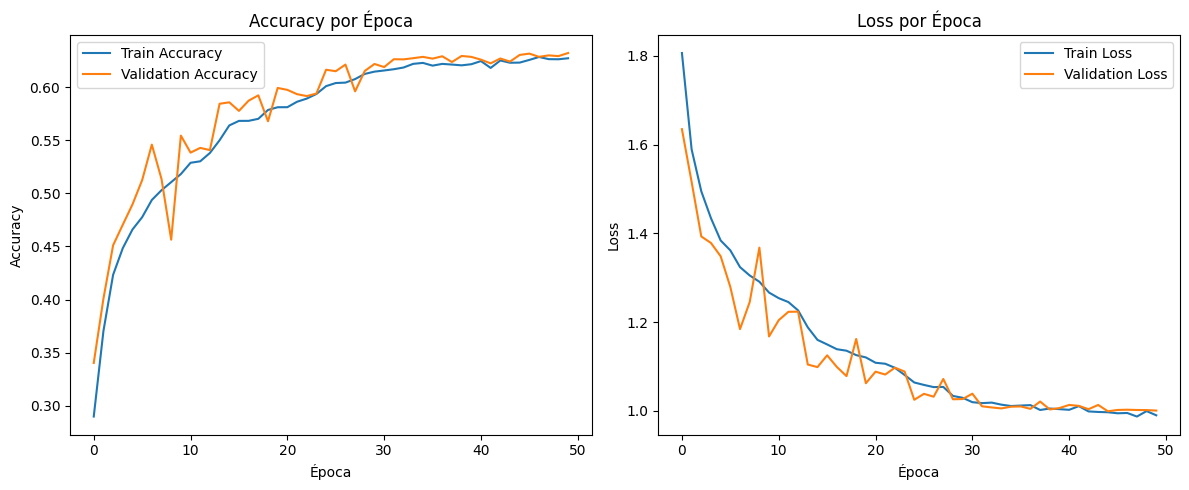

In [12]:
# Gráficas de precisión y pérdida por época
history = model.history.history
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history['accuracy'], label='Train Accuracy')
plt.plot(history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy por Época')
plt.xlabel('Época')
plt.ylabel('Accuracy')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(history['loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Validation Loss')
plt.title('Loss por Época')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.show()

### Matriz de Confusión

113/113 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step


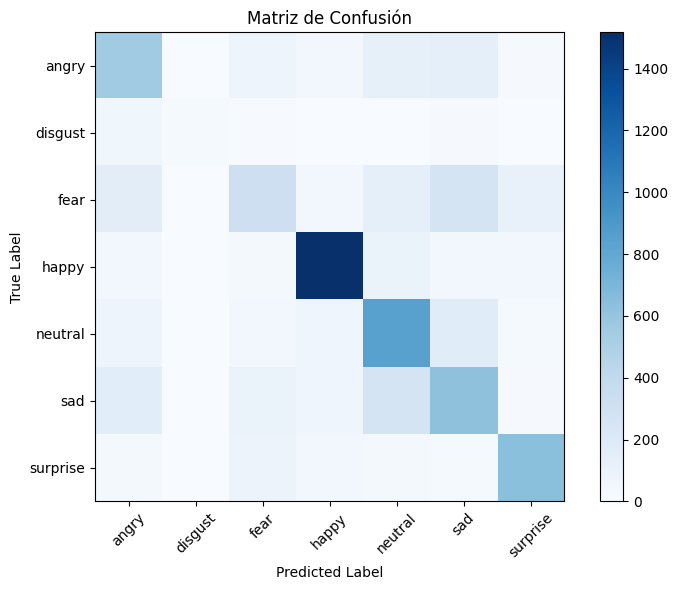

In [13]:
# Matriz de confusión
conf_matrix = confusion_matrix(test_generator.classes, model.predict(test_generator).argmax(axis=1))
plt.figure(figsize=(8, 6))
plt.imshow(conf_matrix, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Matriz de Confusión')
plt.colorbar()
tick_marks = np.arange(len(class_labels))
plt.xticks(tick_marks, class_labels, rotation=45)
plt.yticks(tick_marks, class_labels)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

## Reporte de Clasificación por Clase

In [14]:
# Reporte de clasificación por clase
y_true = test_generator.classes
y_pred = model.predict(test_generator).argmax(axis=1)
report = classification_report(y_true, y_pred, target_names=class_labels)
print('Reporte de Clasificación por Clase:\n')
print(report)

113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step
Reporte de Clasificación por Clase:

              precision    recall  f1-score   support

       angry       0.52      0.58      0.55       958
     disgust       0.80      0.18      0.29       111
        fear       0.49      0.32      0.38      1024
       happy       0.85      0.86      0.85      1774
     neutral       0.56      0.69      0.62      1233
         sad       0.49      0.50      0.50      1247
    surprise       0.76      0.77      0.76       831

    accuracy                           0.63      7178
   macro avg       0.64      0.55      0.56      7178
weighted avg       0.63      0.63      0.62      7178



## 9. Conclusiones

### Rendimiento por clase

El modelo alcanzó una **precisión global de 63%** sobre el conjunto de prueba de FER-2013 (7,178 imágenes, 7 clases). El desempeño varía considerablemente según la emoción:

| Emoción | F1-Score | Observación |
|---------|----------|-------------|
| Happy | 0.85 | Mejor clase; rasgos faciales muy distintivos |
| Surprise | 0.76 | Alta precisión; boca abierta y cejas elevadas son señales claras |
| Neutral | 0.62 | Aceptable; difícil por definición (ausencia de señales) |
| Sad | 0.50 | Confusión frecuente con neutral y angry |
| Angry | 0.55 | Se confunde con disgust y fear |
| Fear | 0.38 | Difícil; comparte rasgos con surprise y sad |
| Disgust | 0.29 | Peor clase; solo 111 muestras en test (desbalance severo) |

### Emociones más difíciles

Las emociones con menor rendimiento comparten una causa raíz: **ambigüedad visual y desbalance de clases**. `disgust` tiene apenas 111 muestras de prueba frente a 1,774 de `happy`, lo que impide al modelo aprender representaciones robustas. `fear` y `sad` comparten microexpresiones similares (comisuras hacia abajo, tensión en cejas), haciendo que el modelo los confunda frecuentemente entre sí y con `neutral`.

### Relevancia para el caso de negocio

Desde la perspectiva del estudio de Sturm et al., el resultado más importante es que `happy` —la emoción central del protocolo de *awe walks*— alcanza **F1 = 0.85**, lo que valida la utilidad del clasificador para el objetivo planteado: rastrear si los participantes del grupo *awe* exhiben mayor frecuencia de expresiones de felicidad a lo largo de las semanas. La detección de `surprise` (F1 = 0.76) también es relevante, ya que el asombro (*awe*) se manifiesta con frecuencia como una combinación de felicidad y sorpresa. El desempeño deficiente en `disgust` y `fear` no representa un obstáculo crítico para este caso de uso específico, ya que esas emociones no son las hipótesis de interés del estudio.

### Mejoras propuestas

1. **Balanceo de clases**: aplicar *oversampling* (SMOTE o augmentation agresiva) sobre las clases minoritarias, particularmente `disgust`.
2. **Transfer learning**: reemplazar la arquitectura desde cero por un modelo pre-entrenado (VGG16, EfficientNetB0) con fine-tuning. En FER-2013, arquitecturas de este tipo alcanzan 70–75% de accuracy.
3. **Adaptación al dominio**: el corpus del estudio consiste en selfies de adultos mayores en exteriores, un dominio diferente al de FER-2013 (imágenes de laboratorio/internet). Un ciclo de *domain adaptation* o fine-tuning sobre una pequeña muestra anotada del corpus real mejoraría significativamente el desempeño.
4. **Umbral por clase**: en producción, usar umbrales de confianza diferenciados por emoción para rechazar predicciones de baja confianza en clases como `fear` y `disgust`.


---
## Referencias

- Sturm, V. E., et al. (2022). *Big smile, small self: Awe walks promote prosocial positive emotions in older adults.* Emotion, 22(5), 1044–1058. https://doi.org/10.1037/emo0000876 — [PMC8034841](https://pmc.ncbi.nlm.nih.gov/articles/PMC8034841/)
- Goodfellow, I. et al. (2013). *Challenges in Representation Learning: A Report on Three Machine Learning Contests.* arXiv:1307.0414
- Dataset FER-2013: https://www.kaggle.com/datasets/msambare/fer2013
- TensorFlow/Keras Documentation: https://www.tensorflow.org/api_docs
- LeCun, Y. et al. (1989). *Backpropagation applied to handwritten zip code recognition.*